# Build a plume-centered EMIT test fixture

The existing `georeader` EMIT fixture is an *arbitrary* 200×200 raw window with no
methane plume, and its orthorectified bbox is sparse (~50% fill), which looks
smeared. Here we build a better fixture:

1. Take a **real EMIT scene that contains plumes** (`20220827T060753_2223904_013`).
2. Subset a **dense 350×350 window at native resolution centered on a real plume**,
   following the *Subset EMIT image* recipe from
   [`emit_explore`](https://spaceml-org.github.io/georeader/emit_explore/#subset-emit-image)
   (`read.read_from_center_coords`).
3. `create_fixture(...)` writes the subset (radiance + OBS + L2A_MASK) to disk as
   standalone EMIT products, reusing the netCDF writer from
   `georeader/tests/data/build_emit_fixture.py`.
4. Reopen the fixture and run the matched filters (`AT_MF_total_EMIT`, `mag1c_emit`)
   to confirm the plume is captured.

In [1]:
%matplotlib inline
import importlib.util
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

import georeader
from georeader.readers import emit
from georeader import read
from georeader.plot import show, add_shape_to_plot
from georeader.save import save_cog

from marshsi.emit.retrieval_upv_emit import AT_MF_total_EMIT
from marshsi.emit.mag1c_emit import mag1c_emit

warnings.filterwarnings('ignore', message="'where' used without 'out'")

## Locate the source scene, plumes and the netCDF writer

The full granule (RAD/OBS/MASK) and the plume polygons live under `tests/data/`.
The netCDF writer is loaded from the sibling `georeader` checkout.

In [2]:
root = Path.cwd().resolve()
while not (root / 'pyproject.toml').exists() and root != root.parent:
    root = root.parent
data = root / 'tests' / 'data'
georeader_repo = root.parent / 'georeader'

SRC_SCENE = '20220827T060753_2223904_013'
src_rad = data / f'EMIT_L1B_RAD_001_{SRC_SCENE}.nc'
plumes_gpkg = data / 'plume_vetting' / 'plumes_emit.gpkg'

# Load the netCDF fixture writer (build_emit_fixture.py) from the georeader checkout.
bef_path = georeader_repo / 'tests' / 'data' / 'build_emit_fixture.py'
spec = importlib.util.spec_from_file_location('build_emit_fixture', bef_path)
bef = importlib.util.module_from_spec(spec); spec.loader.exec_module(bef)

assert src_rad.exists(), src_rad
print('source scene :', src_rad.name, '%.0f MB' % (src_rad.stat().st_size / 1e6))
print('plumes       :', plumes_gpkg.name)
print('netcdf writer:', bef_path)

source scene : EMIT_L1B_RAD_001_20220827T060753_2223904_013.nc 1851 MB
plumes       : plumes_emit.gpkg
netcdf writer: /mnt/batch/tasks/shared/LS_root/mounts/clusters/gonzvml2/code/Users/adm.gmateoga/georeader/tests/data/build_emit_fixture.py


## Pick the largest plume and subset a dense 350×350 window around it

In [3]:
ei = emit.EMITImage(str(src_rad))
print('full scene ortho shape:', ei.shape)

plumes = gpd.read_file(plumes_gpkg).to_crs('EPSG:4326')
plumes['area'] = plumes.geometry.area
plume = plumes.sort_values('area', ascending=False).iloc[0].geometry
lon, lat = float(plume.centroid.x), float(plume.centroid.y)
print(f'largest plume centroid: lon={lon:.4f}, lat={lat:.4f}')

ei_sub = read.read_from_center_coords(
    ei, (lon, lat), shape=(350, 350), crs_center_coords='EPSG:4326'
)
print('subset ortho shape :', ei_sub.shape)
print('subset raw window  :', ei_sub.window_raw)
print('valid GLT pixels   : %d / %d (%.0f%% dense)' % (
    ei_sub.valid_glt.sum(), ei_sub.valid_glt.size, 100 * ei_sub.valid_glt.mean()))

# Spatial resolution: the transform is in EPSG:4326 (degrees); project the
# subset to UTM to read the native pixel size in metres and confirm it is the
# real ~60 m EMIT resolution (not a resampled/coarsened grid).
print('subset transform (EPSG:4326):', repr(ei_sub.transform))
crs_utm_sub = georeader.get_utm_epsg(ei_sub.footprint('EPSG:4326'))
print('subset transform (UTM)      :', repr(ei_sub.to_crs(crs_utm_sub).transform))

full scene ortho shape: (285, 2007, 2239)


largest plume centroid: lon=61.6746, lat=36.4964
subset ortho shape : (285, 350, 350)
subset raw window  : Window(col_off=np.int32(599), row_off=np.int32(128), width=np.int32(412), height=np.int32(411))
valid GLT pixels   : 122500 / 122500 (100% dense)
subset transform (EPSG:4326): Affine(np.float64(0.000542232520256367), np.float64(-0.0), np.float64(61.57998665795424),
       np.float64(0.0), np.float64(-0.000542232520256367), np.float64(36.59115341034274))
subset transform (UTM)      : Affine(60.0, 0.0, 372665.3482014116,
       0.0, -60.0, 4050457.6732119946)


/tmp/claude-1000/ipykernel_42/2669775581.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  plumes['area'] = plumes.geometry.area


RGB of the subset with the plume polygon overlaid — the plume should sit near the
centre and the image should be fully dense (no fill gaps).

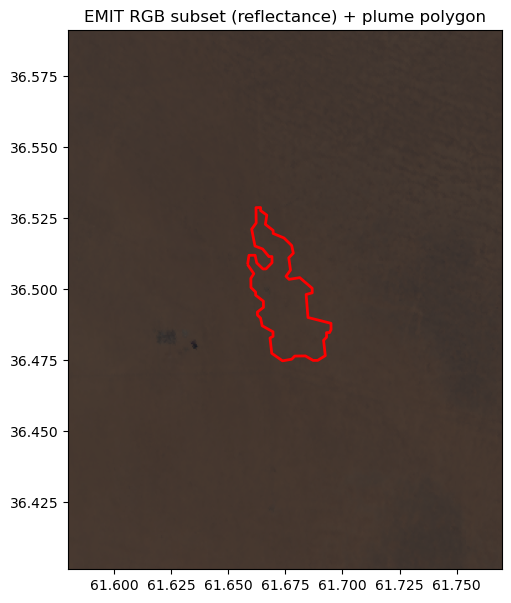

In [4]:
rgb_sub = ei_sub.load_rgb(as_reflectance=True).clip(0, 1)
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
show(rgb_sub, ax=ax, mask=rgb_sub.values == rgb_sub.fill_value_default,
     title='EMIT RGB subset (reflectance) + plume polygon')
add_shape_to_plot(plume, ax=ax, crs_plot=rgb_sub.crs, crs_shape='EPSG:4326',
                  polygon_no_fill=True, kwargs_geopandas_plot={'edgecolor': 'red', 'linewidth': 2})
plt.show()

## `create_fixture` — serialize the subset to standalone EMIT products

Writes the dense 350×350 ortho subset plus its native-resolution raw block
(`window_raw`) as three EMIT netCDFs (RAD/OBS/MASK) whose GLT is rewritten to be
1-based relative to the new raw subset. The companion OBS/MASK source files are the
siblings of the RAD file the subset was opened from.

In [5]:
def create_fixture(emit_image, out_dir, dst_scene):
    """Persist a subset EMITImage as standalone RAD/OBS/MASK fixtures.

    ``emit_image`` is a subset produced by ``read.read_from_center_coords`` /
    ``read_from_window`` (it shares netCDF handles with the full scene and carries a
    cropped GLT + ``window_raw``). The fixture preserves native resolution: the raw
    sensor block is copied verbatim and the orthorectified grid stays dense.
    """
    out = Path(out_dir); out.mkdir(parents=True, exist_ok=True)

    # Raw-sensor window this subset references in the full scene.
    w = emit_image.window_raw
    bef.RAW_Y0, bef.RAW_Y1 = int(w.row_off), int(w.row_off + w.height)
    bef.RAW_X0, bef.RAW_X1 = int(w.col_off), int(w.col_off + w.width)

    # Position of the subset's ortho window inside the full ortho grid, recovered
    # from the two GLT transforms (col/row pixel offset).
    full = emit.EMITImage(emit_image.filename)
    ft, st = full.glt.transform, emit_image.glt.transform
    col_off = int(round((st.c - ft.c) / ft.a))
    row_off = int(round((st.f - ft.f) / ft.e))
    h, wd = emit_image.glt.shape[-2], emit_image.glt.shape[-1]
    grs, gcs = slice(row_off, row_off + h), slice(col_off, col_off + wd)

    # Rewrite GLT indices to be 1-based into the new raw subset.
    gx = emit_image.glt.values[0].astype(np.int32).copy()
    gy = emit_image.glt.values[1].astype(np.int32).copy()
    invalid = ((gx == 0) | (gy == 0) | (gx <= bef.RAW_X0) | (gx > bef.RAW_X1)
               | (gy <= bef.RAW_Y0) | (gy > bef.RAW_Y1))
    gx = gx - bef.RAW_X0; gy = gy - bef.RAW_Y0
    gx[invalid] = 0; gy[invalid] = 0

    # EMIT geotransform order: [ulx, dx_col, dx_row, uly, dy_col, dy_row].
    t = emit_image.glt.transform
    ngt = (t.c, t.a, t.b, t.f, t.d, t.e)

    src_rad = Path(emit_image.filename)
    src_obs = src_rad.parent / src_rad.name.replace('L1B_RAD_001', 'L1B_OBS_001')
    src_mask = src_rad.parent / src_rad.name.replace('L1B_RAD_001', 'L2A_MASK_001')
    specs = [
        (src_rad,  f'EMIT_L1B_RAD_001_{dst_scene}.nc',  'radiance', ['wavelengths', 'fwhm'], {}),
        (src_obs,  f'EMIT_L1B_OBS_001_{dst_scene}.nc',  'obs',      ['observation_bands'], {}),
        (src_mask, f'EMIT_L2A_MASK_001_{dst_scene}.nc', 'mask',     ['mask_bands'],
         {'band_mask': 'u1', 'packed_wavelength_bands': 'f4'}),
    ]
    for src, name, var, sbp, extra in specs:
        bef._build_one(src, out / name, var, sbp, extra, grs, gcs, gx, gy, ngt)
    return out / f'EMIT_L1B_RAD_001_{dst_scene}.nc'

## Write the fixture and validate it round-trips the subset exactly

In [6]:
DST_SCENE = '20220827T060753_9999999_001'  # synthetic id; plume-centered fixture
fixture_dir = data / 'emit_plume_fixture'
fixture_rad = create_fixture(ei_sub, fixture_dir, DST_SCENE)

for p in sorted(fixture_dir.glob('*.nc')):
    print('wrote', p.relative_to(root), '%.1f MB' % (p.stat().st_size / 1e6))

# Reopen and assert the radiance is identical to the in-memory subset.
fix = emit.EMITImage(str(fixture_rad))
a, b = fix.load(as_reflectance=False), ei_sub.load(as_reflectance=False)
m = (a.values != a.fill_value_default) & (b.values != b.fill_value_default)
print('fixture ortho shape:', fix.shape, '| raw:', fix.shape_raw)
print('same_extent        :', a.same_extent(b))
print('radiance identical :', np.array_equal(a.values[m], b.values[m]),
      '(max abs diff %.3g)' % (np.abs(a.values[m] - b.values[m]).max() if m.any() else 0))

/mnt/batch/tasks/shared/LS_root/mounts/clusters/gonzvml2/code/Users/adm.gmateoga/georeader/tests/data/build_emit_fixture.py:201: UserWarning: endian-ness of dtype and endian kwarg do not match, using endian kwarg
  var = dst.createVariable(name, arr.dtype, (dim,))


/mnt/batch/tasks/shared/LS_root/mounts/clusters/gonzvml2/code/Users/adm.gmateoga/georeader/tests/data/build_emit_fixture.py:181: UserWarning: endian-ness of dtype and endian kwarg do not match, using endian kwarg
  var = dst.createVariable(k, arr.dtype, (f"_{k}",))


wrote tests/data/emit_plume_fixture/EMIT_L1B_OBS_001_20220827T060753_9999999_001.nc 6.4 MB
wrote tests/data/emit_plume_fixture/EMIT_L1B_RAD_001_20220827T060753_9999999_001.nc 129.1 MB
wrote tests/data/emit_plume_fixture/EMIT_L2A_MASK_001_20220827T060753_9999999_001.nc 3.8 MB


fixture ortho shape: (285, 350, 350) | raw: (285, np.int32(411), np.int32(412))
same_extent        : True


radiance identical : True (max abs diff 0)


## Helpers: run retrievals → UTM, and plot

As in `docs/emit_example.ipynb`: run the retrievals in the raw sensor frame
(`georeferenced=False`), reproject to UTM (`to_crs`) and georeference every product
with `emit_image_utm.georreference(arr, fill_value_default=-1)`.

`mag1c` is in ppm·m and the WMF/MF products are in ppm. They are plotted on the **same**
physical scale: `mag1c` `vmax=1750` ppm·m, and the matched filters `vmax=1750/8000` ppm
(dividing by the 8000 m atmosphere height). `vmin=0` for all; default (viridis) colormap;
`rad`/`albedo` autoscale.

In [7]:
ATMOSPHERE_HEIGHT_METHANE = 8000.0  # m; WMF[ppm] * height = ppm*m (mag1c units)
MAG1C_VMAX = 1750.0
MF_VMAX = MAG1C_VMAX / ATMOSPHERE_HEIGHT_METHANE
VMAX = {
    'mf_classic': MF_VMAX, 'mf_extended': MF_VMAX, 'mf_combo': MF_VMAX,
    'mf_extended_filtered': MF_VMAX, 'mag1c': MAG1C_VMAX, 'rad': None, 'albedo': None,
}

def retrievals_to_utm(emit_native):
    """Run AT_MF_total_EMIT + mag1c_emit in the raw frame and georeference to UTM."""
    crs_utm = georeader.get_utm_epsg(emit_native.footprint('EPSG:4326'))
    eutm = emit_native.to_crs(crs_utm)
    mf_classic, mf_extended, mf_combo, mf_extended_filtered, rad = AT_MF_total_EMIT(
        emit_native, georeferenced=False
    )
    mfoutput, albedo = mag1c_emit(emit_native, georeferenced=False, display_pbar=False)
    g = lambda a: eutm.georreference(a, fill_value_default=-1)
    products = {
        'mf_classic': g(mf_classic), 'mf_extended': g(mf_extended), 'mf_combo': g(mf_combo),
        'mf_extended_filtered': g(mf_extended_filtered), 'rad': g(rad),
        'mag1c': g(mfoutput), 'albedo': g(albedo),
    }
    return products, eutm

def plot_products(products, plume=None, suptitle=None):
    fig, axes = plt.subplots(3, 3, figsize=(17, 15)); axes = axes.ravel()
    for ax, (name, gt) in zip(axes, products.items()):
        show(gt, ax=ax, mask=True, vmin=0, vmax=VMAX[name],
             add_colorbar_next_to=True, title=name)
        if name == 'mag1c' and plume is not None:
            add_shape_to_plot(plume, ax=ax, crs_plot=gt.crs, crs_shape='EPSG:4326',
                              polygon_no_fill=True,
                              kwargs_geopandas_plot={'edgecolor': 'lime', 'linewidth': 1.5})
    for ax in axes[len(products):]:
        ax.axis('off')
    if suptitle:
        fig.suptitle(suptitle, fontsize=16)
    plt.tight_layout(); plt.show()

## Run on the fixture and persist the products as COGs

The UTM products are written next to the fixture (`emit_plume_fixture/products/`) with
`georeader.save.save_cog` — these are the golden references for the test suite.

In [8]:
products_fix, emit_image_utm = retrievals_to_utm(fix)
print('UTM crs/transform:', emit_image_utm.crs, repr(emit_image_utm.transform))
for name, gt in products_fix.items():
    v = gt.values; mm = (v != gt.fill_value_default) & np.isfinite(v)
    print(f'{name:22s} shape={tuple(gt.shape)} valid={100*mm.mean():.0f}%% '
          f'p2={np.percentile(v[mm],2):.3g} p98={np.percentile(v[mm],98):.3g}')

products_dir = fixture_dir / 'products'
products_dir.mkdir(parents=True, exist_ok=True)
for name, gt in products_fix.items():
    out = products_dir / f'{name}.tif'
    save_cog(gt, str(out))
    print('saved', out.relative_to(root), '%.0f KB' % (out.stat().st_size / 1024))

UTM crs/transform: EPSG:32641 Affine(60.0, 0.0, 372665.3482014116,
       0.0, -60.0, 4050457.6732119946)
mf_classic             shape=(355, 288) valid=97%% p2=-0.0628 p98=0.0778
mf_extended            shape=(355, 288) valid=97%% p2=-0.0414 p98=0.0452
mf_combo               shape=(355, 288) valid=97%% p2=-0.0722 p98=0.0605
mf_extended_filtered   shape=(355, 288) valid=97%% p2=-0.0231 p98=0.0303
rad                    shape=(355, 288) valid=97%% p2=0.872 p98=1.04
mag1c                  shape=(355, 288) valid=97%% p2=0 p98=1.21e+03
albedo                 shape=(355, 288) valid=97%% p2=0.898 p98=1.07


saved tests/data/emit_plume_fixture/products/mf_classic.tif 920 KB


saved tests/data/emit_plume_fixture/products/mf_extended.tif 921 KB
saved tests/data/emit_plume_fixture/products/mf_combo.tif 920 KB


saved tests/data/emit_plume_fixture/products/mf_extended_filtered.tif 793 KB
saved tests/data/emit_plume_fixture/products/rad.tif 401 KB
saved tests/data/emit_plume_fixture/products/mag1c.tif 122 KB


saved tests/data/emit_plume_fixture/products/albedo.tif 375 KB


RGB of the fixture in UTM (sanity check):

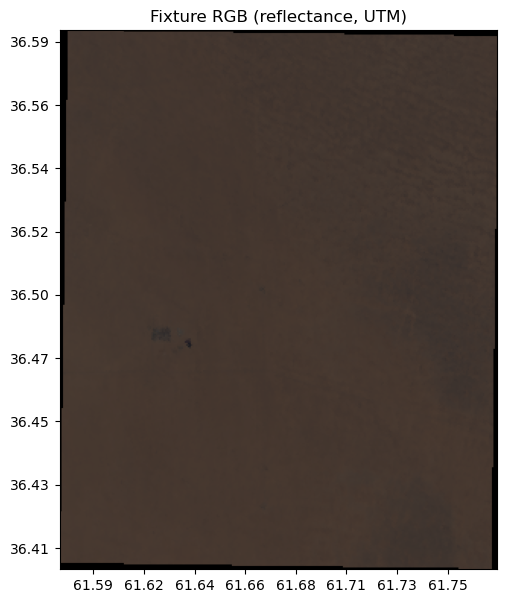

In [9]:
rgb = emit_image_utm.load_rgb(as_reflectance=True).clip(0, 1)
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
show(rgb, ax=ax, mask=rgb.values == rgb.fill_value_default, title='Fixture RGB (reflectance, UTM)')
plt.show()

All fixture products in UTM, plume polygon overlaid on `mag1c`. The extended WMF
(`mf_extended`) — the operationally critical product — resolves the plume here because a
350×350 window gives ~411 raw rows per column, comfortably above the 188 extended bands
the per-column covariance is estimated from. (Smaller windows, e.g. 150×150 with ~177
rows < 188, make that covariance rank-deficient and the WMF washes out — which is why the
fixture uses 350×350.)

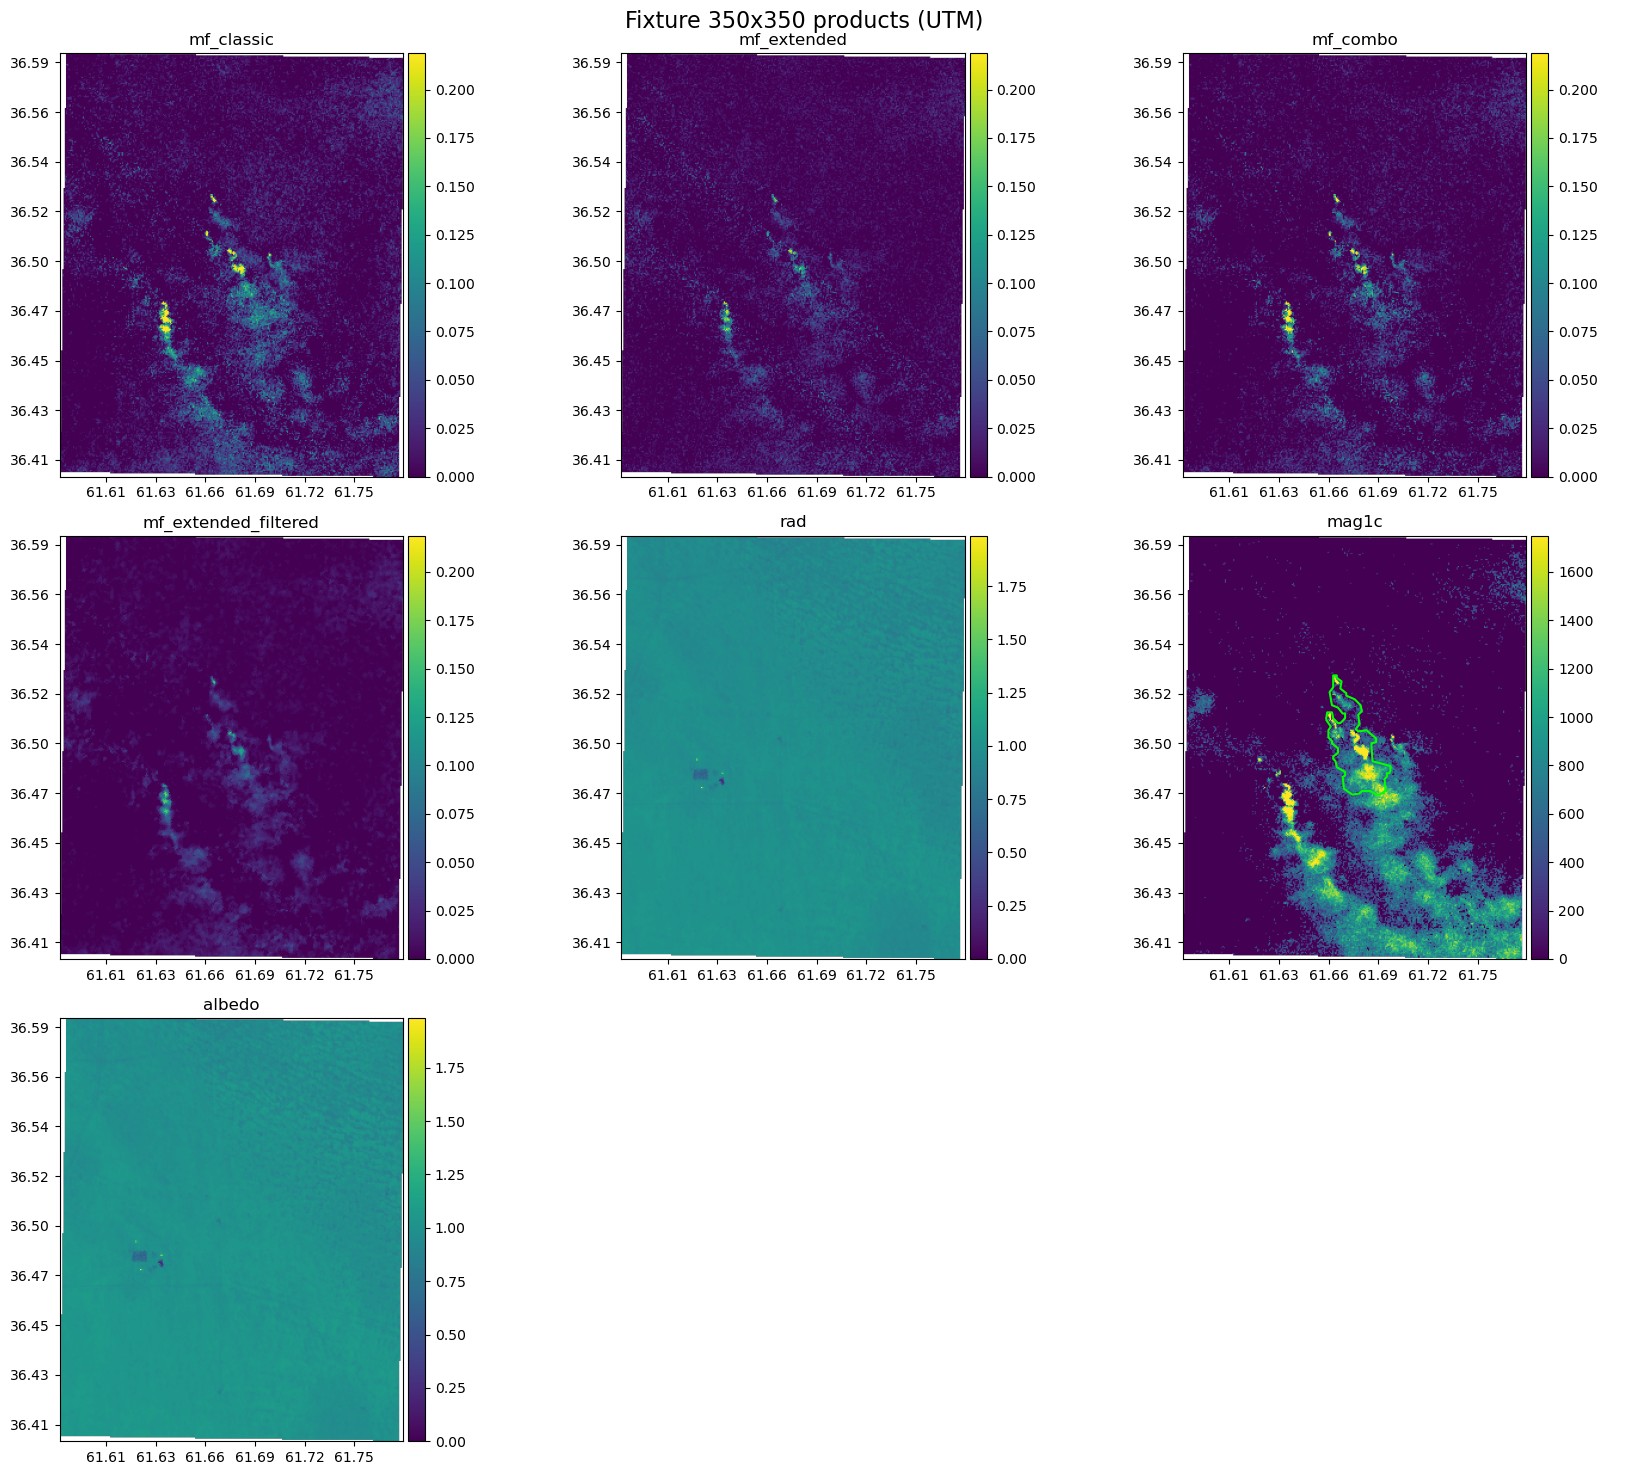

In [10]:
plot_products(products_fix, plume=plume, suptitle='Fixture 350x350 products (UTM)')